# Introduction


**File:** Notebook_to_build_graphics.ipynb 
\
**Author:** Elizabeth Gould
\
**Date:** 10.03.2026
\
**Problem:** Here there are two:
 1) Plot $\Psi(x)$
 2) Test our model for $M_{\mu}\left(BR, dk, \mu, \Psi_0^\prime\right)$

This code contains two short exercises. The first is just a sample of a run of our derivative grid code, which plots the IVP solutions for $\Psi(x)$ The second is a short Monte Carlo test of our model for $M_{\mu}\left(BR, dk, \mu, \Psi_0^\prime\right)$, which contains both visual and numerical analysis.

# Derivative Grids

This is the code used for building the derivative grid graphs with the deriv_grid class of my library.

In [2]:
#--LIBRARIES--------

#numerics
import numpy as np
import eelib

#--CODE--

# set parameters
# note that k, B, and R are percents here, mu is not as its scale is unknown
k = 0.5
R = 1.0
B = 0.5
mu = 1.0e-7

n_g = 5

pr = 1000
n = 1

loopl = eelib.deriv_grid(R, B, k, mu, grid_size=n_g)
loopl.derivGrid()


# --- PLOTTING FOR GRIDS ---
for i in range(n_g):
    for j in range(n_g):
        loopl.plot_abs(i,j,k,R,B,mu,n)
        loopl.plot_real(i,j,k,R,B,mu,n)

Begin grid build:  0.0
Plot Code: ['er', '0r', '0x', 'em'] 35
i =  1 of  5 time:  0.0010137557983398438
Done, i, j =  1 1 time:  425.60918831825256
Done, i, j =  1 2 time:  999.7543675899506
Done, i, j =  1 3 time:  1670.3892183303833
Done, i, j =  1 4 time:  2243.107450723648
Done, i, j =  1 5 time:  2865.3794503211975
i =  2 of  5 time:  2865.394219636917
Done, i, j =  2 1 time:  3425.1825251579285
Done, i, j =  2 2 time:  3972.909587621689
Done, i, j =  2 3 time:  4369.62785243988
Done, i, j =  2 4 time:  4774.924133777618
Done, i, j =  2 5 time:  5237.2201454639435
i =  3 of  5 time:  5237.236102104187
Done, i, j =  3 1 time:  5627.000266313553
Done, i, j =  3 2 time:  6041.5580015182495
Done, i, j =  3 3 time:  6338.41552567482
Done, i, j =  3 4 time:  6732.538671731949
Done, i, j =  3 5 time:  7079.623293161392
i =  4 of  5 time:  7079.645211935043
Done, i, j =  4 1 time:  7499.045262813568
Done, i, j =  4 2 time:  7839.223477840424
Done, i, j =  4 3 time:  8120.520606517792
Done

# Test of Slow Oscillation Wavenumber Model

This is code to visually and numerically test the fit of my slow oscillation model. The model is not perfect, but good enough.

In [ ]:
import eelib
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#--PARAMETERS--------

# note that k, B, and R are percents here, mu is not as its scale is unknown
dk = 0.5
R  = 1.0
B  = 0.5
mu = 1.0e-6

n_mc = 10

b_r  = (0.5, 1.0)  # B here is B*R
mu_r = (-8, -6)    # 1.0e-8 to 1.0e-6


In [3]:
#--CODE--

# Make the grid object
gridl = eelib.grid_slow_osc(R, B, dk, mu)

# Save our full solution
gridl.save_solution = True

# Make the grid
gridl.makeMCPoints(mu=mu_r, B=b_r, num = n_mc)

# Run the grid
gridl.mcSlowOsc()

Begin grid build:  0.0
Number of periods to calculate: 10
Done grid build:  1436.7411334514618


In [25]:
# First, declare which solution I am using
ii  = int(np.random.rand()*n_mc)
if ii >= n_mc: ii = n_mc - 1 # just in case
sol = gridl.slow_osc_sol[ii]

# Retrieve my fits for this function from the grid.
MM    = gridl.slow_osc_k[ii]
amp   = gridl.slow_osc_a[ii]
theta = gridl.slow_osc_th[ii]

# Predicted slow oscillation amplitude.
vt = gridl.val_table[ii] # mu, dk, B, R, A, k0, dr, di
MM2 = eelib.pred_slow_k(vt[6]+1j*vt[7], vt[0], vt[0], vt[2]*eelib.B_max, vt[3]*eelib.R_max, vt[4], vt[5]) #dpsi0, mu, dk, B, R, A = 1., k0=kFAu

# Pull the found solution from the sol variable.
t_list  = sol['t']
y1_list = np.real(sol['y'][0])

# Estimated fit
y2_list = amp * np.sin(MM2 * (t_list) + theta)

# Fit to a sin using SciPy
y3_list = amp * np.sin(MM * t_list + theta)

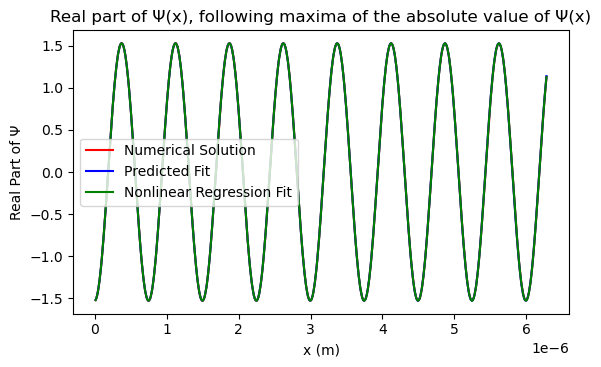

In [26]:
# And plot the results
fig, ax = plt.subplots()

ax.set_ylabel('Real Part of \u03A8')
ax.set_xlabel('x (m)')
plt.title(f"Real part of \u03A8(x), following maxima of the absolute value of \u03A8(x)")

line1, = ax.plot(t_list, y1_list, color = 'red', label = 'Numerical Solution')
line2, = ax.plot(t_list, y2_list, color = 'blue', label = 'Predicted Fit')
line3, = ax.plot(t_list, y3_list, color = 'green', label = 'Nonlinear Regression Fit')

ax.legend(handles=[line1,line2,line3])
ax.set_box_aspect(2.0/3.5)

plt.show()

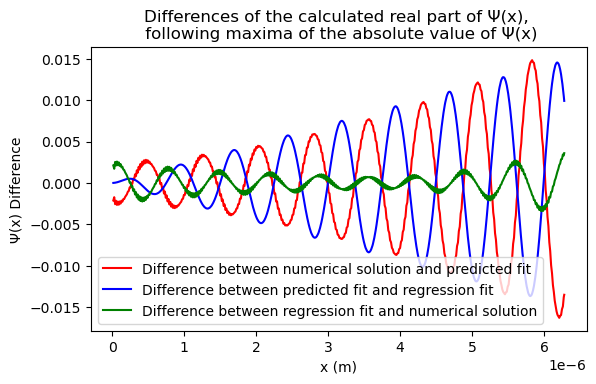

In [27]:
# Plot differences
fig, ax = plt.subplots()

ax.set_ylabel('\u03A8(x) Difference')
ax.set_xlabel('x (m)')
plt.title(f"Differences of the calculated real part of \u03A8(x), \n following maxima of the absolute value of \u03A8(x)")

line1, = ax.plot(t_list, y1_list-y2_list, color = 'red', label = 'Difference between numerical solution and predicted fit')
line2, = ax.plot(t_list, y2_list-y3_list, color = 'blue', label = 'Difference between predicted fit and regression fit')
line3, = ax.plot(t_list, y3_list-y1_list, color = 'green', label = 'Difference between regression fit and numerical solution')

ax.legend(handles=[line1,line2,line3])
ax.set_box_aspect(2.0/3.5)

plt.show()

In [28]:
# Print the differences
print(f"Estimated slow oscillation wavenumber: {MM2}")
print(f"Fit slow oscillation wavenumber: {MM}")
print("Maximum difference between regression fit and predicted fit:", np.max(y3_list-y2_list))
print("Maximum difference between numerical solution and predicted fit:", np.max(y1_list-y2_list))
print("Maximum difference between numerical solution and regression fit:", np.max(y1_list-y3_list))

Estimated slow oscillation wavenumber: 8389300.433092475
Fit slow oscillation wavenumber: 8387761.299876148
Maximum difference between regression fit and predicted fit: 0.013657253183702513
Maximum difference between numerical solution and predicted fit: 0.01481728630082968
Maximum difference between numerical solution and regression fit: 0.0034084309286432912


In [24]:
# Now for the rest of the numbers
for ii in range(n_mc):
    # First, declare which solution I am using
    sol = gridl.slow_osc_sol[ii]

    # Retrieve my fits for this function from the grid.
    MM    = gridl.slow_osc_k[ii]
    amp   = gridl.slow_osc_a[ii]
    theta = gridl.slow_osc_th[ii]

    # Predicted slow oscillation amplitude.
    vt = gridl.val_table[ii] # mu, dk, B, R, A, k0, dr, di
    MM2 = eelib.pred_slow_k(vt[6]+1j*vt[7], vt[0], vt[0], vt[2]*eelib.B_max, vt[3]*eelib.R_max, vt[4], vt[5]) #dpsi0, mu, dk, B, R, A = 1., k0=kFAu

    # Pull the found solution from the sol variable.
    t_list  = sol['t']
    y1_list = np.real(sol['y'][0])

    # Estimated fit
    y2_list = amp * np.sin(MM2 * (t_list) + theta)

    # Fit to a sin using SciPy
    y3_list = amp * np.sin(MM * t_list + theta)

    # Print the differences
    print(f"Random solution {ii}")
    print(f"Estimated slow oscillation wavenumber: {MM2}")
    print(f"Fit slow oscillation wavenumber: {MM}")
    print("Maximum difference between regression fit and estimated fit:", np.max(y3_list-y2_list))
    print("Maximum difference between numerical solution and estimated fit:", np.max(y1_list-y2_list))
    print("Maximum difference between numerical solution and regression fit:", np.max(y1_list-y3_list))
    print("")

Random solution 0
Estimated slow oscillation wavenumber: 7695931.0389159145
Fit slow oscillation wavenumber: 7705523.901747796
Maximum difference between regression fit and estimated fit: 0.08855178629225899
Maximum difference between numerical solution and estimated fit: 0.09008886877059123
Maximum difference between numerical solution and regression fit: 0.003557607193861667

Random solution 1
Estimated slow oscillation wavenumber: 5520152.083362719
Fit slow oscillation wavenumber: 5521561.8786500525
Maximum difference between regression fit and estimated fit: 0.007871258831689008
Maximum difference between numerical solution and estimated fit: 0.007910053928197436
Maximum difference between numerical solution and regression fit: 0.0011458076251886773

Random solution 2
Estimated slow oscillation wavenumber: 10306056.140563946
Fit slow oscillation wavenumber: 10313521.234371202
Maximum difference between regression fit and estimated fit: 0.07582130778922336
Maximum difference between